In [3]:
import numpy as np
import pandas as pd
# Load CSV dataset
train_df = pd.read_csv('fashion-mnist_train.csv')
test_df = pd.read_csv('fashion-mnist_test.csv')

train_df.head()

# Since image size is:28 × 28 = 784 pixels
# there are:784 pixel columns.

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
train_df.shape

(60000, 785)

In [7]:
# Split features and labels
X_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values

In [9]:
# Scale pixel values (0–255 → 0–1) Normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0

In [15]:
# Convert to 28x28 images with 1 channel (Reshape for CNN)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# our Fashion MNIST CSV data is initially flat.
# Each image has:28 × 28 = 784 pixels
# So one image looks like:[0, 0, 0, 255, 34, ...]
# Shape of dataset:(60000, 784)

# Meaning:
# 60,000 images
# each image = 784 values in one row

# But CNN does not understand flat rows properly.
# It expects actual image dimensions.

# Why Channel = 1?
# Fashion MNIST images are:grayscale images.
# Grayscale has:only one color channel.

# -1 means:“Automatically calculate number of images.”

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# Convolution + pooling
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(2,2))

# Flatten + Dense
model.add(Flatten())
model.add(Dense(64, activation='relu'))

model.add(Dropout(0.2))

# Output layer (10 classes)
model.add(Dense(10, activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\praja\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 5408)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         346,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Train model
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.8328 - loss: 0.4761 - val_accuracy: 0.8835 - val_loss: 0.3233
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 63s 37ms/step - accuracy: 0.8854 - loss: 0.3233 - val_accuracy: 0.8960 - val_loss: 0.2921
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.8988 - loss: 0.2819 - val_accuracy: 0.9062 - val_loss: 0.2640
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - accuracy: 0.9082 - loss: 0.2549 - val_accuracy: 0.9077 - val_loss: 0.2542
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.9137 - loss: 0.2343 - val_accuracy: 0.9118 - val_loss: 0.2506


In [22]:
# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9179 - loss: 0.2343
Test Accuracy: 0.917900025844574
Test Loss: 0.2343212217092514


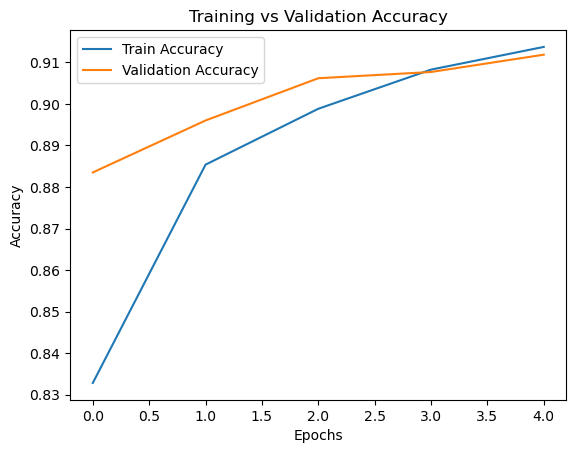

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


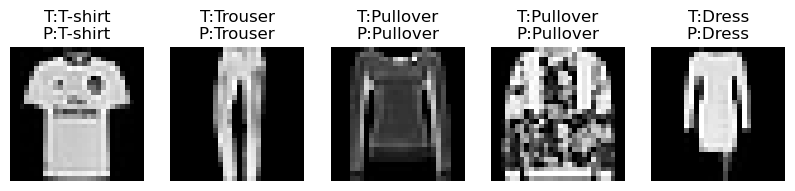

In [26]:
# Sample Predictions
labels = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
          'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

y_pred = np.argmax(model.predict(X_test), axis=1)

plt.figure(figsize=(10,3))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"T:{labels[y_test[i]]}\nP:{labels[y_pred[i]]}")
    plt.axis('off')
plt.show()

In [28]:
from sklearn.metrics import confusion_matrix, classification_report

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1000
           1       0.99      0.98      0.99      1000
           2       0.91      0.85      0.88      1000
           3       0.91      0.94      0.93      1000
           4       0.85      0.91      0.88      1000
           5       0.99      0.98      0.98      1000
           6       0.81      0.70      0.75      1000
           7       0.95      0.96      0.96      1000
           8       0.98      0.98      0.98      1000
           9       0.97      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [30]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
print(cm)

[[902   0  10  16   1   2  61   0   8   0]
 [  2 985   2   9   2   0   0   0   0   0]
 [ 16   1 849  12  71   0  48   0   3   0]
 [ 20   5   5 941  19   0  10   0   0   0]
 [  0   0  24  21 911   0  43   0   1   0]
 [  0   1   0   0   0 979   0  11   2   7]
 [161   1  43  30  60   0 700   0   5   0]
 [  0   0   0   0   0   9   0 965   0  26]
 [  3   1   3   0   3   1   6   3 980   0]
 [  0   0   0   0   0   1   0  32   0 967]]


<Figure size 600x500 with 0 Axes>